In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
DATA_PATH = Path("../data/raw/mvtec_ad")
category = "bottle"
defect_type = "broken_small"
image_id = "000"

image_path = DATA_PATH/category/"test"/defect_type/f"{image_id}.png"
mask_path = DATA_PATH/category/"ground_truth"/defect_type/f"{image_id}_mask.png"

image = Image.open(image_path)
mask = Image.open(mask_path)

image.mode, image.size, mask.mode, mask.size

('RGB', (900, 900), 'L', (900, 900))

In [4]:
mask_array = np.array(mask)
mask_array.shape, mask_array.dtype, mask_array.min(), mask_array.max()

((900, 900), dtype('uint8'), np.uint8(0), np.uint8(255))

In [5]:
np.unique(mask_array)

array([  0, 255], dtype=uint8)

## Binary mask and defected area

- Ground truth mask uses pixel values 0 and 255.
- 0 means no defect / 255 means defect
- For computation we convert the mask into binary array: False/0 means no defect...True/1 means defect

This lets us cound defective pixels and calculate how much of the image is actually defected.

In [6]:
binary_mask = mask_array > 0
binary_mask.shape, binary_mask.dtype, binary_mask.sum()

((900, 900), dtype('bool'), np.int64(7166))

In [7]:
total_pixels = binary_mask.size
defect_pixels = binary_mask.sum()

defect_area_percent = defect_pixels/total_pixels *100
total_pixels, defect_pixels, defect_area_percent

(810000, np.int64(7166), np.float64(0.8846913580246915))

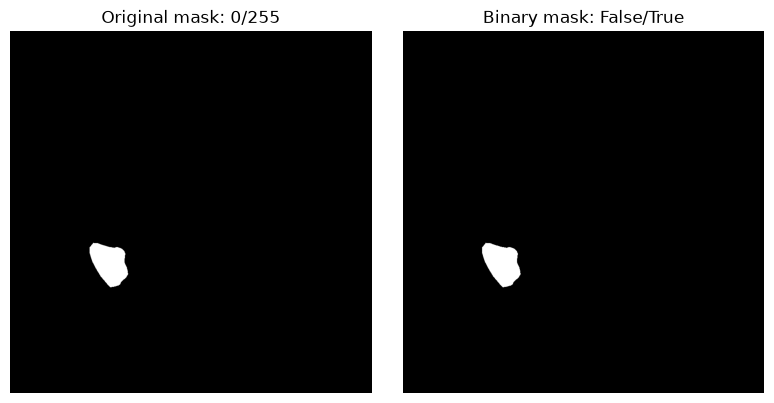

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(mask_array, cmap="gray")
axes[0].set_title("Original mask: 0/255")
axes[0].axis("off")

axes[1].imshow(binary_mask, cmap="gray")
axes[1].set_title("Binary mask: False/True")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Observation
The defect covers less than 1% of the image area in this example. This shows that pixel-level anomaly segmentation is highly imbalanced: most pixels are normal.

Because of this, pixel accuracy would be misleading. A model could predict no defect everywhere and still get very high pixel accuracy. Later we will use metrics such as IoU, Dice, F1, and pixel level AUROC instead.

## Defect Bounding Box
A binary mask tells us exactly which pixels are defective.
A bounding box summarizes the defective region using four coordinates.
This gives a simple rectangular region around the defect.
- `x_min`: left edge
- `x_max`: right edge
- `y_min`: top edge
- `y_max`: bottom edge

In [9]:
ys, xs = np.where(binary_mask)
print(f"Number of defect pixels: {len(xs)}")
print("First five x coordinates:", xs[:5])
print("First five y coordinates:", ys[:5])

Number of defect pixels: 7166
First five x coordinates: [207 206 207 208 209]
First five y coordinates: [526 527 527 527 527]


In [10]:
x_min = xs.min()
x_max = xs.max()
y_min = ys.min()
y_max = ys.max()

x_min, y_min, x_max, y_max

(np.int64(198), np.int64(526), np.int64(293), np.int64(636))

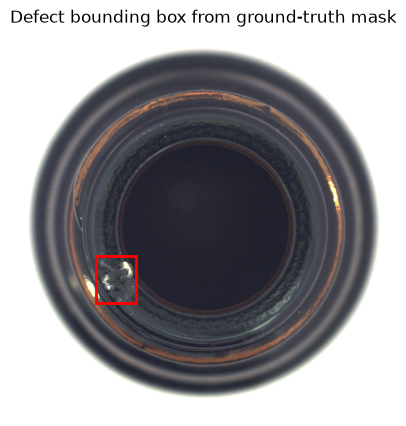

In [11]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image)
width = x_max - x_min
height = y_max - y_min

rect = patches.Rectangle(
    (x_min, y_min),
    width,
    height,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)

ax.add_patch(rect)
ax.set_title("Defect bounding box from ground-truth mask")
ax.axis("off")
plt.show()

## Mask stats across categories
Now we calculate defect area for every available ground truth mask. This helps us understand which categories contain small or large defects and how difficult pixel level localization may be.

In [16]:
mask_rows = []

for category_path in sorted(DATA_PATH.iterdir()):
    if not category_path.is_dir():
        continue
    category = category_path.name
    ground_truth_path = category_path / "ground_truth"
    if not ground_truth_path.exists():
        continue
    for defect_type_path in sorted(ground_truth_path.iterdir()):
        if not defect_type_path.is_dir():
            continue
        defect_type = defect_type_path.name
        for mask_path in sorted(defect_type_path.glob("*.png")):
            mask = Image.open(mask_path)
            mask_array = np.array(mask)
            binary_mask = mask_array > 0
            
            total_pixels = binary_mask.size
            defect_pixels = binary_mask.sum()
            defect_area_percent = defect_pixels / total_pixels * 100
            
            mask_rows.append({
                "category": category,
                "defect_type": defect_type,
                "mask_path": mask_path,
                "defect_pixels": defect_pixels,
                "defect_area_percent": defect_area_percent,
            })
mask_stats = pd.DataFrame(mask_rows)
mask_stats.head()

,category,defect_type,mask_path,defect_pixels,defect_area_percent
0,bottle,broken_large,../data/raw/mvtec_ad/bottle/ground_truth/broke...,88192,10.887901
1,bottle,broken_large,../data/raw/mvtec_ad/bottle/ground_truth/broke...,76641,9.461852
2,bottle,broken_large,../data/raw/mvtec_ad/bottle/ground_truth/broke...,125835,15.535185
3,bottle,broken_large,../data/raw/mvtec_ad/bottle/ground_truth/broke...,222091,27.418642
4,bottle,broken_large,../data/raw/mvtec_ad/bottle/ground_truth/broke...,33132,4.090370


In [13]:
mask_stats.groupby("category")["defect_area_percent"].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
bottle,63.0,7.616561,5.760058,0.575679,2.574136,5.717778,12.829074,27.418642
cable,92.0,4.681168,3.682743,0.143623,2.229786,3.680801,6.117558,22.580719
capsule,109.0,1.108877,1.840285,0.037100,0.247900,0.429500,0.849600,8.078700
hazelnut,70.0,3.354637,5.339422,0.232887,0.916910,1.615810,2.854824,27.658558
screw,119.0,0.335478,0.166602,0.098515,0.232124,0.287914,0.398397,1.010799


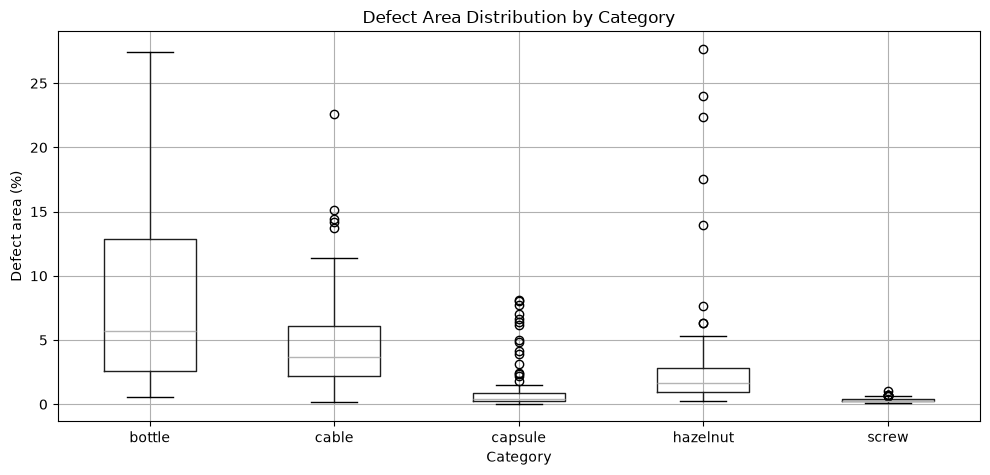

In [14]:
ax = mask_stats.boxplot(
    column="defect_area_percent",
    by="category",
    figsize=(10, 5),
)

ax.set_title("Defect Area Distribution by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Defect area (%)")

plt.suptitle("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Observation
The defect area varies strongly across categories. Some categories contain very small defects, which makes pixel level localization difficult.